[![Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/giordamaug/decouple_emb_lgbm/blob/main/notebook.ipynb)

## Libraries

In [19]:
import torch
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter(action='ignore')
import numpy as np
import os
import random
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"       # to force BERT determinsm

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # per multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)

## Load dataset

In [20]:
import sys
sys.path.append('.')
from scripts.utils import Settings

dataset = "INA_orig"
if dataset == "INA_orig":
    datafile =  "data/dataset_14_04_26_EN.json"
    target_var = "is_alive?"
    evfields = ['event']
    static_vars = ["gender", "age_group", "base_pathology_area"]
    remove_events = ['followup', 'platelet', 'bmi_change', 'thrombosys']
    no_selection = False
    thresh = 0.3
elif dataset == "INA":
    datafile =  "dataset_14_04_26_EN_final.json"
    static_vars = ["gender", "age_at_splenectomy", "base_pathology_area"]
    target_var = "is_alive?"
    evfields = ['event']
    remove_events = ['followup', 'platelet', 'bmi_change', 'thrombosys']
    no_selection = False
    thresh = 0.3
elif dataset == "MIMIC":
    datafile = "mimic-iv_asplenic_4133_final.json"
    #datafile = "../SysBiology_paper/mimic-iv_asplenic_1368.json"
    static_vars = ["gender", "age_at_splenectomy", "base_pathology_area"]
    target_var = "is_alive?"
    evfields = ['event']
    remove_events = ['drug'] #, 'therapy']
    no_selection = True
    thresh = 0.25
else:
    raise Exception("dataset not supported!")
args = Settings(datafile = datafile, 
                no_selection=no_selection,
                pathology_field = 'base_pathology_area', #'base_pathology_area', # 'primarys_disease'
                static_vars= static_vars,
                target_var = target_var,
                pathologies={'Asplenic Syndromes' : 'AS', 
                            'Autoimmune Hematological Diseases' : 'AIHD', 
                            'Congenital Hemolytic Anemias' : 'CHA', 
                            'Immunodeficiencies' : 'IM', 
                            'NTDT - (Non Transfusion Dependent Thalassemia - Intermediate Thalassemia)' : 'NTDT', 
                            'Non-Hemato-Oncological Causes' : 'NHOC', 
                            'Oncological Diseases' : 'OD', 
                            'SCD - (Sickle Cell Disease, Anemia/Sickle Cell or Sickle Cell Disease)' : 'SCD', 
                            'TDT - (Transfusion Dependent Thalassemia - Thalassemia Major)' : 'TDT'},
                spleen_flags = ['YES', 'NO'],
                selected_spleen_flags = ['YES'],
                methods=['LSTM', 'GRU', 'GRU-D', 'BEHRT', 'Dipole', 'DOME', 'BINARY'],
                evfields = evfields,
                remove_events = remove_events,
                save_events=False,
                enable_plot=True, 
                n_splits=5, 
                num_epochs=10, 
                batch_size = 16, 
                embedding_size=128,
                hidden_size=300)

Loaded 1492 records from data/dataset_14_04_26_EN.json


### Remove patients with specific cause of death

In [21]:
if "cause_of_death" in args.dataset.columns:
    words = ["accident", "trauma", "suicide", "fracture", "malignant", "myeloma"]
    pattern = "|".join(words)
    args.dataset = args.dataset[~args.dataset["cause_of_death"].str.contains(pattern, case=False, na=False)]
    args.selected_patient_ids = args.dataset.index
    print("Patients no:", len(args.selected_patient_ids))

Patients no: 1487


### Remove patients with no events

In [22]:
args.dataset = args.dataset[args.dataset["events"].apply(lambda x: x != [])]
args.selected_patient_ids = args.dataset.index
print("Patients no:", len(args.selected_patient_ids))

Patients no: 1486


## Plot patients distribution

Index(['Congenital Hemolytic Anemias',
       'TDT - (Transfusion Dependent Thalassemia - Thalassemia Major)',
       'NTDT - (Non Transfusion Dependent Thalassemia - Intermediate Thalassemia)',
       'Autoimmune Hematological Diseases',
       'SCD - (Sickle Cell Disease, Anemia/Sickle Cell or Sickle Cell Disease)',
       'Non-Hemato-Oncological Causes', 'Oncological Diseases',
       'Immunodeficiencies', 'Asplenic Syndromes'],
      dtype='object', name='base_pathology_area')


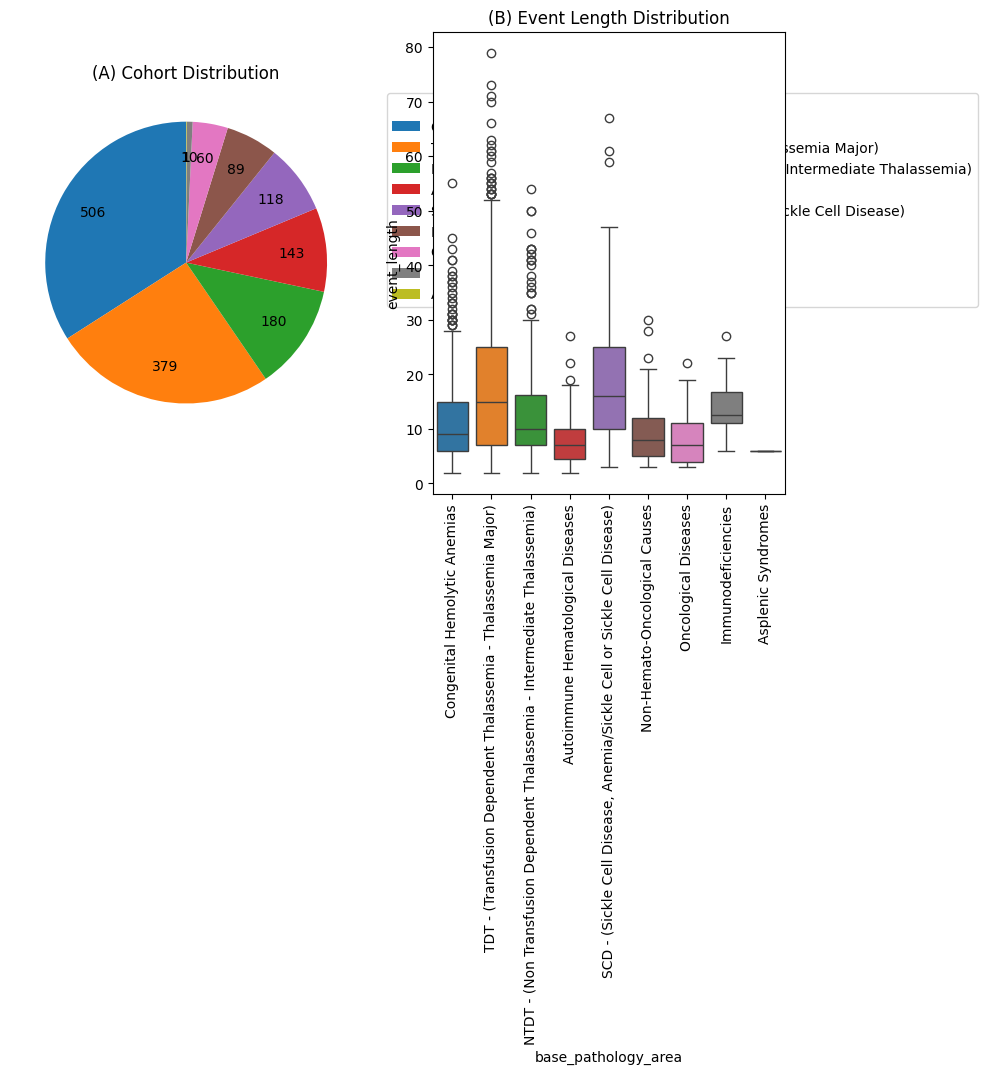

In [23]:
if "base_pathology_area" in args.dataset.columns:
    from scripts.utils import plot_group_distribution_with_event_boxplot
    plot_group_distribution_with_event_boxplot(args.dataset, groupby=args.pathology_field)#, label_desc=args.pathologies)

## Get clinical trajectories

In [24]:
from scripts.utils import count_events_by_type
events_field, date_field, type_field = 'events', 'date', 'type'
event_sequences = { id: [(" ".join([event[field] for field in args.evfields]), event[date_field], event[type_field]) for event in events] for (id,events) in args.dataset[[events_field]].to_dict()[events_field].items()} 


### Remove events by types

n.1486 Patients
Index(['Congenital Hemolytic Anemias',
       'TDT - (Transfusion Dependent Thalassemia - Thalassemia Major)',
       'NTDT - (Non Transfusion Dependent Thalassemia - Intermediate Thalassemia)',
       'Autoimmune Hematological Diseases',
       'SCD - (Sickle Cell Disease, Anemia/Sickle Cell or Sickle Cell Disease)',
       'Non-Hemato-Oncological Causes', 'Oncological Diseases',
       'Immunodeficiencies', 'Asplenic Syndromes'],
      dtype='object', name='base_pathology_area')


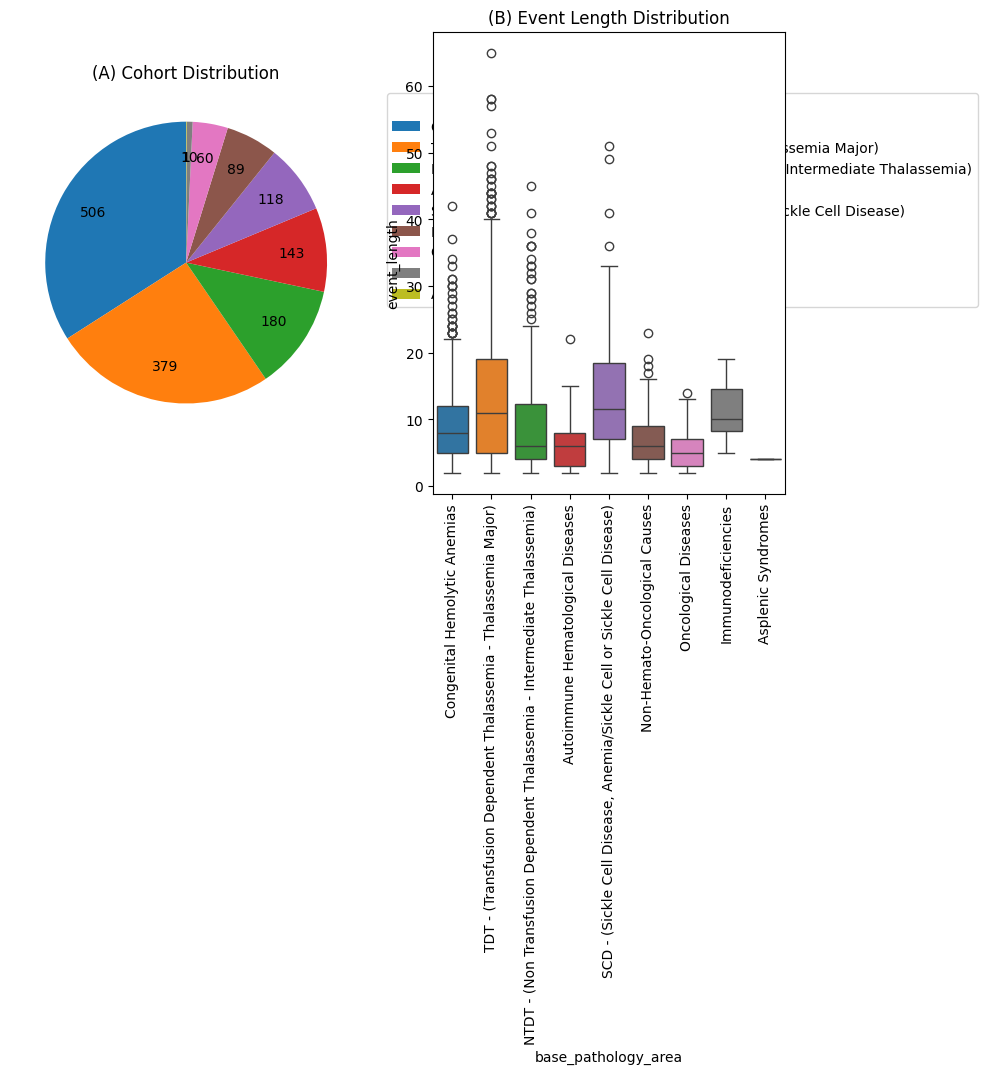

In [25]:
from scripts.utils import group_events_by_visit
# get sequence of event names
event_sequences = { id: [(" ".join([event[field] for field in args.evfields]), event[date_field]) for event in events if event[type_field] not in args.remove_events] for (id,events) in args.dataset[[events_field]].to_dict()[events_field].items()} 
event_sequences_type = { id: [(" ".join([event[field] for field in args.evfields]), event[date_field], event[type_field]) for event in events if event[type_field] not in args.remove_events] for (id,events) in args.dataset[[events_field]].to_dict()[events_field].items()} 
visit_sequences = group_events_by_visit(event_sequences)
args.dataset['events'] = args.dataset.apply(lambda row: event_sequences[row.name], axis=1)
print(f"n.{len(event_sequences)} Patients")
if "base_pathology_area" in args.dataset.columns:
    from scripts.utils import plot_group_distribution_with_event_boxplot
    plot_group_distribution_with_event_boxplot(args.dataset, groupby=args.pathology_field)#, label_desc=args.pathologies)

In [26]:
event_sequences = { id: events for (id,events) in event_sequences.items() if len(events) > 0 } 
args.selected_patient_ids = np.array(list(event_sequences.keys()))

### count event by type and cardinality

In [27]:
if False:
    cnt_df = count_events_by_type(event_sequences_type)
    cnt_df

In [28]:
count_events_by_type(event_sequences_type)

,cardinality,n. instances,set
type,,,
surgical_operation,18,1561,"{nevus excision, appendectomy, cord surgery, b..."
therapy,39,4998,"{transfusion, antimalarial, oxygen, antidepres..."
vaccination,9,6548,"{vaccine meningococcus C, vaccine Hib, vaccine..."
infection,36,555,{bacterial/viral infection of the oral mucous ...
platelet_change,2,1216,"{basso, alta}"
comorbidity,15,830,"{cardiovascular diseases, diseases of the nerv..."


### save sequences

In [29]:
if args.save_events:
      import pickle
      with open(f'data/{dataset}_{len(args.selected_patient_ids)}_{"-".join(evfields)}_events.txt','wb') as f:
            pickle.dump(event_sequences, f)
      with open(f'data/{dataset}_{len(args.selected_patient_ids)}_{"-".join(evfields)}_visits.txt','wb') as f:
            pickle.dump(visit_sequences, f)

## Get static variables

In [30]:
if len(args.static_vars) > 0:
    mapper = {'pediatric': 0, 'adolescent' : 1, 'adult': 2, 'ND' : -1, 'young': 0, 'mature' : 1, 'elder': 2, 'geriatric': 3}
    X_static = args.dataset.loc[args.selected_patient_ids][args.static_vars].copy()
    X_static.replace(mapper, inplace=True)
    cnames = list(X_static.select_dtypes(include=['object']).columns)
    for col in cnames:
        X_static[col], _ = pd.factorize(X_static[col])
else:
    X_static = pd.DataFrame(index=args.selected_patient_ids)
X_static

,gender,age_group,base_pathology_area
id,,,
1,0,0,0
2,1,0,1
3,0,0,1
4,1,0,1
5,0,0,2
...,...,...,...
1948,1,0,1
1949,1,0,1
1950,1,2,1


## Get targets

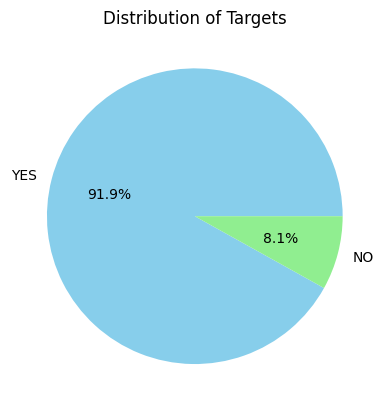

In [31]:
import matplotlib.pyplot as plt
target_df = args.dataset[args.target_var].copy()
target_df.replace({"n/a": "YES", np.nan: "YES"}, inplace=True)
counts = target_df.value_counts()
counts.plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'lightgreen'])
plt.title('Distribution of Targets')
plt.ylabel('')
target_df.replace({"YES": 0, "NO": 1}, inplace=True)
target_df.to_csv(f"data/{dataset}_targets.csv")
plt.show()

In [32]:
target_df.value_counts(dropna=False)

is_alive?
0    1366
1     120
Name: count, dtype: int64

## Validate

In [33]:
from scripts.configure import configure
embedder_configs = configure(event_sequences, visit_sequences, target_df.to_dict(), X_static, args)

#Create empty dataframe for results collections
cols = ["AUC mean","AUC std","F1 mean","F1 std","Prec mean","Prec std","Recall mean","Recall std","MCC mean","MCC std","Acc mean","Acc std","CM"]
dtypes = {"AUC mean": "float64", "AUC std": "float64","F1 mean": "float64","F1 std": "float64","Prec mean": "float64","Prec std": "float64","Recall mean": "float64","Recall std": "float64","MCC mean": "float64","MCC std": "float64","Acc mean": "float64","Acc std": "float64", "CM": "string", "Brier": "float64"}

# Pre-allocate empty DataFrame with correct dtypes
results_df = pd.DataFrame(
    {c: pd.Series(dtype=dt) for c, dt in dtypes.items()},
    columns=cols
)

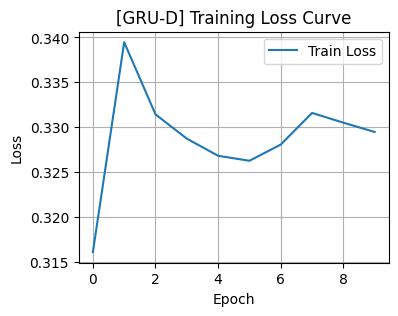

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[24]	valid_0's MCC: 0.414949
Train data (1189, 303) - Test data (297, 303)

📊 Risultati medi su 5 fold:
📈 AUC:      0.8817 ± 0.0138
🧪 F1-score: 0.5000 ± 0.0256
⚖️ Precision:0.3864 ± 0.0170
🔁 Recall:   0.7167 ± 0.0928
🧮 MCC:      0.4701 ± 0.0377
🎯 Accuracy: 0.8849 ± 0.0079
🎲 Brier:     0.0637

🧩 Confusion Matrix finale (aggregata):
[[1229  137]
 [  34   86]]

📉 Calibration curve:
prob_pred = [0.02389755 0.13755328 0.25137854 0.34976261 0.45548864 0.54051795
 0.65029573 0.7523027  0.85687841 0.94068835]
prob_true = [0.01745201 0.11842105 0.12195122 0.175      0.09090909 0.55555556
 0.53125    0.1875     0.53125    0.56      ]


In [34]:
if True:
    from scripts.cv_folding import lgbm_cv
    args.methods = [#['STATIC'],
                    #['STATIC', 'BiPadLSTM'], 
                    #['STATIC', 'M2V'],
                    #['STATIC', 'Dipole'],
                    #['STATIC', 'DOME']
    ['STATIC', 'GRU'],['STATIC', 'GRU-D']]
    for m in args.methods:
        set_seed(args.random_state)
        results_tmp, model, train_df, test_df, y_train, y_test= lgbm_cv(embedder_configs, target_df, args.selected_patient_ids,
                                                                        methods=m, threshold=thresh)
        results_df = pd.concat([results_df, results_tmp],axis=0)
    results_df

In [35]:
results_df.to_csv("q.csv")

# END 

In [17]:
if False:
    results_df.to_csv(f"results_{dataset}_final.csv")

# End-TO-END CLASSIFIFICATION

In [18]:
from scripts.cv_folding import e2e_cv
args.methods = ['M2V']
for m in args.methods:
    set_seed(args.random_state)
    results_tmp, y_train, y_test= e2e_cv(embedder_configs, target_df, args.selected_patient_ids,
                                                                    method=m)
    results_df = pd.concat([results_df, results_tmp],axis=0)
results_df

,AUC mean,AUC std,F1 mean,F1 std,Prec mean,Prec std,Recall mean,Recall std,MCC mean,MCC std,Acc mean,Acc std,CM,Brier
M2V,0.845485,0.023161,0.220774,0.10441,0.557137,0.259978,0.15,0.085797,0.242854,0.103539,0.918575,0.008866,"[[1347, 19], [102, 18]]",0.062552
